# Distilling the Knowledge in a Neural Network
**Authors:** Geoffrey Hinton, Oriol Vinyals, Jeff Dean (Google Inc.)

# https://arxiv.org/pdf/1503.02531

## Abstract
This paper introduces "distillation," a general technique for transferring the knowledge learned by a large, cumbersome model (or ensemble of models) into a single small model better suited for deployment. Building on prior work by Caruana et al., the authors propose using a softened probability distribution over classes — produced by raising the "temperature" of the cumbersome model's softmax — as "soft targets" for training the small model. Distillation achieves surprising results on MNIST, significantly improves the acoustic model of a heavily used commercial speech recognition system, and motivates a new ensemble structure combining a generalist model with many parallelizable "specialist" models for distinguishing fine-grained, confusable classes.

## Problems
- Ensembles of models (or single very large, strongly regularized models) generally achieve better performance than individual models by capturing more structure from large, redundant training data, but deploying an entire ensemble to many users is computationally expensive and impractical due to latency and resource constraints.
- The conventional identification of a model's "knowledge" with its specific learned parameter values makes it conceptually difficult to see how knowledge could be transferred to a differently-structured (smaller) model while being preserved.
- Standard training objectives optimize performance on training data (via hard, one-hot labels) rather than directly targeting the true objective of generalizing well to new data, and information about how a model should generalize is not normally available for training smaller models.
- When class probabilities from a cumbersome model are very confident (e.g., near 0 or 1, as in MNIST), most of the informative "dark knowledge" about relative similarities between classes is compressed into extremely small probability ratios that have negligible effect on the cross-entropy loss during naive transfer training.
- For datasets with very large numbers of classes (e.g., JFT's 15,000 labels), training a full ensemble of large models is prohibitively computation-intensive, even though ensemble training is easy to parallelize.
- Specialist models trained on small, highly enriched subsets of confusable classes are prone to severe overfitting due to their effectively small training sets.
- Mixtures of experts, an existing approach to leveraging class subsets, are difficult to parallelize because expert assignments and the gating network's training depend on comparing all experts' performance on the same examples simultaneously.

## Proposed Solutions
1. **Knowledge distillation via softened softmax**: Redefine class probabilities using a temperature parameter $T$:
$$q_i = \frac{\exp(z_i/T)}{\sum_j \exp(z_j/T)}$$
Using a higher $T$ produces a softer probability distribution that reveals more information about the cumbersome model's learned similarity structure between classes.
2. **Training the distilled model on soft targets**: Train the small model using a high temperature (matching the cumbersome model's transfer-time temperature) to match these soft targets, then deploy the trained distilled model at $T=1$.
3. **Combined objective with hard and soft targets**: Use a weighted average of two cross-entropy objectives — one against the high-temperature soft targets, one against the true hard labels at $T=1$ — with a considerably lower weight on the hard-target term, and scale soft-target gradients by $T^2$ to keep relative contributions stable across different temperatures.
4. **Theoretical connection to logit matching**: Show that in the high-temperature limit, with zero-meaned logits, distillation reduces to Caruana et al.'s method of directly minimizing $\frac{1}{2}(z_i - v_i)^2$ between cumbersome and distilled model logits — establishing logit matching as a special case of distillation.
5. **Specialist model ensembles for very large class sets**: Train one generalist model on all classes plus many specialist models, each initialized from the generalist's weights and trained on data enriched for a specific highly confusable subset of classes (with all other classes collapsed into a single "dustbin" class), enabling fast, fully parallel training.
6. **Automatic class clustering for specialists**: Use online K-means clustering applied to the covariance matrix of the generalist model's predictions to automatically derive confusable class groupings, without requiring true labels or an explicit confusion matrix.
7. **Soft targets as regularizers**: Demonstrate that soft targets alone (without early stopping) can prevent severe overfitting when training on small data fractions, offering a principled alternative regularization strategy.

## Purpose
The purpose was to develop and validate a practical, general-purpose method for compressing the generalization capability of large, cumbersome models (ensembles or heavily regularized single large networks) into smaller models suitable for real-world deployment with strict latency and resource constraints, while retaining as much of the original model's performance and — critically — its learned generalization behavior as possible.

## Methodology
- **Distillation gradient derivation**: For a transfer case with distilled-model logit $z_i$ and cumbersome-model logit $v_i$, the cross-entropy gradient with respect to $z_i$ at temperature $T$ is:
$$\frac{\partial C}{\partial z_i} = \frac{1}{T}(q_i - p_i) = \frac{1}{T}\left(\frac{e^{z_i/T}}{\sum_j e^{z_j/T}} - \frac{e^{v_i/T}}{\sum_j e^{v_j/T}}\right)$$
For high $T$ relative to logit magnitudes, this approximates to:
$$\frac{\partial C}{\partial z_i} \approx \frac{1}{NT^2}(z_i - v_i)$$
(assuming zero-meaned logits), showing distillation converges to logit matching at high temperature.
- **MNIST experiments**: A cumbersome net (two hidden layers, 1200 ReLUs each, trained on all 60,000 cases with dropout, weight constraints, and input jittering) was compared against a smaller net (two hidden layers, 800 ReLUs, no regularization), with and without distillation from the cumbersome net at temperature 20. Additional experiments tested distillation with 30-unit hidden layers across varying temperatures, and transfer sets with entire digit classes (3s, or 7s/8s only) omitted.
- **Speech recognition (ASR) experiments**: An 8-hidden-layer DNN (2560 ReLUs per layer, 14,000-label softmax, ~85M parameters) trained via frame-level cross-entropy against forced-alignment HMM state labels, using ~2000 hours (~700M examples) of English speech data. A baseline model was compared against a 10-model ensemble and a single model distilled from that ensemble (temperatures tested: 1, 2, 5, 10; hard-target relative weight of 0.5), evaluated via frame accuracy and Word Error Rate (WER) on a 23K-word test set.
- **JFT specialist ensemble experiments**: JFT is Google's internal dataset with 100 million images and 15,000 labels; the baseline was a deep CNN trained for ~6 months via asynchronous distributed SGD. 61 specialist models (300 classes plus dustbin each) were trained, initialized from generalist weights, each on data with half its examples from its confusable class subset (derived via online K-means clustering of the generalist's prediction covariance matrix) and half randomly sampled from the rest of the data.
- **Specialist ensemble inference**: For a test image, the $n=1$ most probable classes under the generalist define the active specialist set $A_k$; the final distribution $\mathbf{q}$ is found by minimizing:
$$KL(\mathbf{p}^g, \mathbf{q}) + \sum_{m \in A_k} KL(\mathbf{p}^m, \mathbf{q})$$
optimized per-image via gradient descent on the logits $\mathbf{z}$ (with $\mathbf{q} = \text{softmax}(\mathbf{z})$, $T=1$).
- **Regularization test**: Retrained the 85M-parameter speech baseline model on only 3% of the training data (~20M examples) using hard targets alone (with early stopping) versus soft targets (from the full-data-trained model, no early stopping needed).

## Results

| Experiment | Baseline | Improved System | Metric |
|---|---|---|---|
| MNIST (regularized big net) | — | 67 test errors | Test errors |
| MNIST (small net, no regularization) | 146 test errors | — | Test errors |
| MNIST (small net + distillation, T=20) | — | 74 test errors | Test errors |
| MNIST (transfer set omits all 3s, bias-corrected) | — | 109 errors total (14 on 3s, 98.6% of 3s correct) | Test errors |
| MNIST (transfer set = only 7s/8s, bias-corrected) | 47.3% error | 13.2% error | Test error rate |
| Speech: Baseline | 58.9% / 10.9% | — | Frame accuracy / WER |
| Speech: 10x Ensemble | — | 61.1% / 10.7% | Frame accuracy / WER |
| Speech: Distilled single model | — | 60.8% / 10.7% | Frame accuracy / WER |
| JFT: Baseline | 43.1% / 25.0% | — | Conditional / overall test accuracy |
| JFT: +61 specialist models | — | 45.9% / 26.1% (4.4% relative improvement) | Conditional / overall test accuracy |
| Speech, 3% data, hard targets (early stopped) | 44.5% test accuracy (severe overfitting) | — | Test frame accuracy |
| Speech, 3% data, soft targets (no early stopping) | — | 57.0% test accuracy | Test frame accuracy |
| Speech, 100% data baseline (reference ceiling) | — | 58.9% test accuracy | Test frame accuracy |

- Distillation transferred over 80% of the frame-classification accuracy improvement achieved by the 10-model speech ensemble into a single distilled model of the same size as the baseline, with the corresponding WER improvement (10.9% → 10.7%) also fully transferred.
- On MNIST, when hidden layers had ≥300 units, all temperatures above 8 gave similar distillation results; when reduced to 30 units per layer, intermediate temperatures (2.5–4) worked significantly better, suggesting that ignoring very negative logits (which carry noisier information) benefits smaller distilled models.
- Distillation succeeded even under zero-shot-like conditions: a model trained on a transfer set entirely lacking examples of digit "3" still correctly classified 98.6% of test 3s after a simple bias correction, demonstrating that generalization knowledge (not just direct class examples) transfers through soft targets.
- JFT specialist ensemble accuracy improvements grew with the number of specialists covering a given class, ranging from +3.4% relative accuracy improvement (1 specialist) to +16.6% (9 specialists), while specialists trained in a few days each compared to many weeks for full ensemble members.
- Soft targets alone (without early stopping) allowed the 85M-parameter speech model to recover nearly all the performance of full-dataset training (57.0% vs. 58.9%) using only 3% of the data, compared to severe overfitting (44.5%, requiring early stopping) with hard targets on the same reduced data — demonstrating soft targets' strong implicit regularization effect.
- Distillation achieved substantially larger relative improvement over a comparable prior approach (Li et al., 2014), which used temperature-1 distillation on unlabeled data and recovered only 28% of the large-small model performance gap, versus this paper's approach recovering the large majority of the ensemble's improvement.

## Conclusions
Distillation is established as an effective and general method for transferring the generalization capability of large, cumbersome models or ensembles into single smaller models suitable for practical deployment, working well even when transfer data lacks examples of entire target classes. Nearly all of the performance benefit of a full acoustic model ensemble was successfully compressed into a single deployable model of standard size for a real commercial speech recognition system. For settings where even training a full ensemble is computationally infeasible due to very large class counts (e.g., JFT's 15,000 labels), the introduced specialist-model ensemble — trained via fast, fully parallelizable, confusable-class-focused specialization — offers a practical alternative to both traditional ensembling and mixtures of experts, though the authors note that distilling specialist knowledge back into a single large model remains unexplored future work. The findings collectively support high-temperature softened targets as both an effective knowledge-transfer mechanism and a powerful implicit regularizer, particularly valuable in limited-data regimes.

# Mathematical and Statistical Content in "Distilling the Knowledge in a Neural Network"

## 1. Temperature-Scaled Softmax

$$q_i = \frac{\exp(z_i/T)}{\sum_j \exp(z_j/T)}$$

- $z_i$: the logit (pre-softmax input) for class $i$.
- $T$: a temperature parameter, normally set to 1 for standard classification.
- $q_i$: the resulting "soft" probability assigned to class $i$.

**Role:** This is the central mathematical device of the paper. Raising $T$ above 1 flattens (softens) the probability distribution over classes, revealing the relative probabilities the cumbersome model assigns to *incorrect* classes — information that is nearly invisible at $T=1$ when the correct class dominates with near-certainty. These softened probabilities become the "soft targets" used to transfer knowledge to the smaller distilled model.

## 2. Distillation Training Objective

A weighted combination of two cross-entropy losses:
1. Cross-entropy between the distilled model's soft predictions (at high $T$) and the cumbersome model's soft targets (at the same $T$).
2. Cross-entropy between the distilled model's hard predictions (at $T=1$) and the true labels.

**Role:** Using only soft targets transfers the cumbersome model's learned generalization behavior; adding a (lower-weighted) hard-target term anchors the distilled model to ground truth when true labels are available. The paper found the best results came from weighting the hard-target term considerably less than the soft-target term.

## 3. Gradient Scaling by $T^2$

Since the magnitude of gradients produced by the soft-target cross-entropy scales as $1/T^2$ (shown below), the paper multiplies the soft-target loss term by $T^2$ when combining it with the hard-target loss.

**Role:** This keeps the relative contribution of the soft- and hard-target objectives roughly constant even as $T$ is varied during hyperparameter search, preventing the need to re-tune the loss weighting every time the temperature changes.

## 4. Cross-Entropy Gradient with Respect to Distilled Model Logits

For a transfer case, with the distilled model's logits $z_i$, the cumbersome model's logits $v_i$ (producing soft targets $p_i$), and transfer temperature $T$:

$$\frac{\partial C}{\partial z_i} = \frac{1}{T}(q_i - p_i) = \frac{1}{T}\left(\frac{e^{z_i/T}}{\sum_j e^{z_j/T}} - \frac{e^{v_i/T}}{\sum_j e^{v_j/T}}\right)$$

**Role:** This is the exact gradient the distilled model receives during training via backpropagation on the soft-target cross-entropy loss. It directly drives the small model's logits toward reproducing the cumbersome model's softened output distribution.

## 5. High-Temperature Approximation

When $T$ is large relative to the magnitude of the logits, the exponentials can be linearized ($e^x \approx 1+x$ for small $x$):

$$\frac{\partial C}{\partial z_i} \approx \frac{1}{T}\left(\frac{1+z_i/T}{N + \sum_j z_j/T} - \frac{1+v_i/T}{N + \sum_j v_j/T}\right)$$

- $N$: the total number of classes.

**Role:** This is an intermediate algebraic simplification of the exact gradient (Equation 2), obtained by approximating the softmax's exponential terms as first-order Taylor expansions, valid when the temperature is high enough to make $z_i/T$ and $v_i/T$ small.

## 6. Zero-Mean Logit Simplification and Equivalence to Logit Matching

Assuming the logits are zero-meaned separately for each transfer example, i.e. $\sum_j z_j = \sum_j v_j = 0$, the approximation above simplifies to:

$$\frac{\partial C}{\partial z_i} \approx \frac{1}{NT^2}(z_i - v_i)$$

**Role:** This is the paper's key theoretical result: in the high-temperature limit (with zero-meaned logits), the gradient of the distillation loss is proportional to $(z_i - v_i)$ — exactly the gradient of a squared-error loss $\frac{1}{2}(z_i - v_i)^2$. This formally proves that Caruana et al.'s earlier method of directly matching cumbersome and distilled model *logits* is a special case of distillation, occurring at the high-temperature limit. It also explains why the choice of temperature matters: at lower $T$, distillation naturally down-weights logits that are far below average (and potentially noisy), whereas high-$T$ distillation (or direct logit matching) treats all logit differences equally.

## 7. Specialist Model Inference via KL Divergence Minimization

Given a test image, with the generalist model's distribution $\mathbf{p}^g$ and each active specialist model's distribution $\mathbf{p}^m$ (over its confusable classes plus one "dustbin" class), the full probability distribution $\mathbf{q}$ over all classes is found by minimizing:

$$KL(\mathbf{p}^g, \mathbf{q}) + \sum_{m \in A_k} KL(\mathbf{p}^m, \mathbf{q})$$

where $KL$ denotes Kullback-Leibler divergence, and $A_k$ is the "active set" of specialists whose confusable class subset overlaps with the generalist's top predicted class(es).

**Role:** This is the statistical objective used to combine the generalist's and multiple specialists' opinions into a single coherent probability distribution at inference time. Since a specialist's distribution $\mathbf{p}^m$ only covers its own subset of classes plus a dustbin class, its KL divergence term is computed by summing $\mathbf{q}$'s probability mass over all of the specialist's "don't care" classes into a single dustbin probability before comparison. The paper notes this optimization problem has no general closed-form solution and is solved per-image via gradient descent on the logits $\mathbf{z}$ (with $\mathbf{q} = \text{softmax}(\mathbf{z})$, $T=1$), except in the special case where all models output single point-mass probabilities, in which case the solution reduces to either the arithmetic mean (using $KL(\mathbf{p}, \mathbf{q})$) or geometric mean (using $KL(\mathbf{q}, \mathbf{p})$) of the individual distributions.

## 8. Specialist Bias Correction for Oversampling

After training a specialist on data with half its examples drawn from its special class subset (oversampled relative to the full data distribution), the dustbin class logit is corrected by adding the log of the oversampling proportion.

**Role:** This is a statistical correction for sampling bias: since the specialist was trained on an artificially class-balanced (enriched) subset rather than the natural data distribution, its raw dustbin-class probability would be miscalibrated; adding the log-oversampling-ratio to the logit re-calibrates the specialist's output to reflect the true prior probability of the dustbin category under the natural data distribution.

## 9. Online K-Means Clustering on the Prediction Covariance Matrix

An online version of the K-means clustering algorithm is applied to the columns of the covariance matrix of the generalist model's class predictions, to automatically identify sets of classes $S^m$ that are frequently predicted together (i.e., commonly confused).

**Role:** This is the statistical method used to automatically define which classes each specialist model should focus on, without requiring access to true labels or an explicit confusion matrix — classes whose predicted probabilities co-vary strongly (i.e., are often confused with one another by the generalist) are grouped into the same specialist's target set.

## 10. Frame-Level Acoustic Model Training Objective

$$\theta = \arg\max_{\theta'} P(h_t \mid s_t; \theta')$$

- $s_t$: acoustic observation at time $t$.
- $h_t$: the "correct" HMM state at time $t$, determined via forced alignment with the ground-truth word sequence.
- $\theta$: the acoustic model's parameters.

**Role:** This is the standard maximum-likelihood training objective for the DNN acoustic model used in the paper's speech recognition experiments — a frame-by-frame classification task minimizing cross-entropy between predicted and forced-aligned HMM state labels, which serves as the baseline task onto which distillation from a 10-model ensemble is applied.

## 11. Evaluation Metrics (Statistical Performance Measures)

- **Test error count / test error rate**: primary metric for MNIST experiments (e.g., 67 vs. 146 vs. 74 errors out of 10,000 test images).
- **Frame classification accuracy**: fraction of correctly predicted HMM states per acoustic frame, used for the speech recognition experiments (Tables 1, 5).
- **Word Error Rate (WER)**: standard ASR evaluation metric measuring transcription errors relative to a reference transcript, evaluated on a 23K-word test set (Table 1).
- **Top-1 conditional and unconditional test accuracy**: for JFT experiments (Table 3), conditional accuracy restricts evaluation to examples belonging to specialist classes and predictions within that class subset, while overall accuracy considers the full 15,000-class problem.
- **Relative accuracy change**: percentage improvement in top-1 correct classifications broken down by the number of specialists covering a given class (Table 4), used to demonstrate that accuracy gains scale with the degree of specialist coverage.

**Role:** These metrics collectively provide the empirical basis for evaluating how much of an ensemble's (or larger model's) performance is successfully "distilled" into a smaller model, across three very different domains (digit classification, speech recognition, large-scale image classification).

## Summary of Statistical/Mathematical Contribution
The paper's core mathematical contribution is the temperature-parameterized softmax and its gradient analysis, which provides a rigorous theoretical bridge between two knowledge-transfer techniques — showing that direct logit matching (a prior heuristic method) is mathematically a limiting case of the more general distillation framework at high temperature. This is complemented by a practical statistical toolkit (KL-divergence-based ensemble combination, covariance-based clustering, and bias correction for biased sampling) enabling the specialist-ensemble approach to scale to problems with tens of thousands of classes.

# Problems, Limitations, and Proposed Solutions in "Distilling the Knowledge in a Neural Network"

| # | Key Problem / Research Gap | How This Limited Prior Work | Proposed Solution in This Paper |
|---|---|---|---|
| 1 | Ensembles of models (or very large, strongly regularized single models) achieve superior performance but are computationally cumbersome and expensive to deploy to many users due to latency and resource constraints | This created a fundamental tension between the models best suited for extracting structure from large training datasets and the models required for practical, real-time deployment | Introduce "distillation," a general training technique for transferring the knowledge learned by a cumbersome model into a smaller, more deployable model while preserving most of its performance |
| 2 | Knowledge in a trained model is conventionally identified with its specific learned parameter values, making it conceptually unclear how to transfer that knowledge to a differently-structured (smaller) model | This "conceptual block" limited investigation of model compression approaches, since it was not obvious how a small model could inherit a large model's learned behavior without inheriting its exact architecture | Adopt a more abstract view of knowledge as a learned mapping from inputs to outputs, freeing it from any particular parameter instantiation, and enabling transfer via matching output behavior rather than parameters |
| 3 | Standard training objectives optimize performance on training data via hard, one-hot labels, rather than directly targeting the true objective of generalizing well to new, unseen data | Models trained only on hard targets have no direct signal about how to generalize the way a well-generalizing cumbersome model does, since this generalization information is not normally available during training | Use the cumbersome model's softened class probabilities ("soft targets") as training signal for the small model, allowing it to learn to generalize in the same way as the cumbersome model |
| 4 | When a cumbersome model is highly confident (as on tasks like MNIST), most information about learned class similarity structure is encoded in extremely small probability ratios among incorrect classes, which have negligible influence on the cross-entropy loss during naive soft-target training | This made it difficult to effectively transfer the "dark knowledge" contained in a confident model's relative confusion patterns (e.g., which digits look like which) using standard-temperature soft targets | Introduce temperature scaling of the softmax ($q_i = \exp(z_i/T)/\sum_j \exp(z_j/T)$) to soften the probability distribution at high $T$, making previously negligible probability ratios influential during training |
| 5 | Caruana et al.'s prior approach circumvented the small-probability problem by matching cumbersome and distilled model logits directly via squared error, but the theoretical relationship between this method and a more general soft-target transfer approach was unclear | Without this connection, logit matching and soft-target training were treated as separate, unrelated techniques, obscuring how temperature choice relates to logit-matching behavior | Formally derive that logit matching is a special case of distillation in the high-temperature limit (with zero-meaned logits), unifying the two approaches and clarifying how temperature controls attention to large negative (potentially noisy) logits |
| 6 | For datasets with very large numbers of classes (e.g., JFT's 15,000 labels), training a full ensemble of large models is prohibitively computation-intensive at training time, even though ensemble training is easy to parallelize across replicas | This made standard ensembling impractical for extremely large-scale problems, since waiting months or years to train multiple full-scale models was not a viable option for improving a production baseline model | Introduce specialist models — trained rapidly and independently on highly confusable class subsets, initialized from a generalist model's weights — as a fast, parallelizable alternative to training full additional ensemble members |
| 7 | Specialist models that focus on fine-grained, confusable class distinctions tend to overfit severely because their effectively enriched training subsets are much smaller than the full dataset | This overfitting problem could not be solved by simply reducing specialist model size, since doing so would sacrifice the beneficial transfer effects gained from modeling non-specialist classes | Show that soft targets (used in addition to, or potentially instead of, hard targets and early stopping) act as an effective regularizer, allowing specialists to retain knowledge of non-specialist classes while learning fine-grained distinctions |
| 8 | Deriving meaningful class groupings for specialist models traditionally required access to true labels and computation of a full confusion matrix | This added complexity and labeling requirements that could limit scalability of the specialist approach to very large, potentially weakly-labeled datasets | Apply online K-means clustering directly to the covariance matrix of the generalist model's predictions, deriving confusable class clusters without requiring true labels or an explicit confusion matrix |
| 9 | Mixtures of experts, an existing method for leveraging class subsets via a gating network, are difficult to parallelize because each expert's weighted training set depends on all other experts, and the gating network must compare experts' performance on the same examples during training | This difficulty meant mixtures of experts were rarely used in the large-dataset regime where they might be most beneficial, limiting their practical adoption at scale | Propose a simpler alternative: first train a generalist model and define specialist class subsets independently of a gating network (via clustering), after which specialists can be trained entirely independently and in parallel |
| 10 | It was unknown whether a small model trained with limited data could avoid severe overfitting without relying on early stopping, particularly when replicating the performance of a model trained on much larger data | Prior approaches to training under data scarcity relied primarily on early stopping and other standard regularizers, which only partially mitigate overfitting and require careful tuning of stopping criteria | Demonstrate that soft targets alone, without early stopping, allow a model trained on only 3% of the data to recover nearly all the performance of the full-data-trained baseline, establishing soft targets as a strong implicit regularizer |

In [1]:
# ============================================================
# Simplified Educational Replication of Core Ideas from:
# "Distilling the Knowledge in a Neural Network"
# (Hinton, Vinyals, Dean, 2015)
#
# This replication implements the paper's core knowledge distillation
# technique:
#   1) Train a larger "teacher" (cumbersome) CNN normally.
#   2) Train a smaller "student" (distilled) CNN using a WEIGHTED
#      combination of:
#        a) Soft-target loss: KL divergence between the student's
#           and teacher's temperature-softened softmax outputs
#           (Eq. 1: q_i = exp(z_i/T) / sum_j exp(z_j/T))
#        b) Hard-target loss: standard cross-entropy against true
#           labels (at T=1)
#      with the soft-target loss scaled by T^2, as specified in the
#      paper, to keep gradient magnitudes balanced across temperatures.
#   3) For comparison, also train a "baseline student" of the SAME
#      small size but WITHOUT distillation (hard labels only), to
#      directly illustrate the transfer benefit of distillation —
#      the paper's central empirical claim.
#
# Dataset: CIFAR-10 loaded exclusively from HuggingFace
# Framework: PyTorch
# NOTE: This code is provided for copy/paste into a notebook.
# It is NOT executed here.
# ============================================================

# ---- Imports ----
import io
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix
from IPython.display import display, Image as IPImage

In [2]:
# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# ------------------------------------------------------------
# 2. Class names (CIFAR-10, exact order — labels 0-9)
# ------------------------------------------------------------
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
NUM_CLASSES = len(CLASS_NAMES)

In [ ]:
# ------------------------------------------------------------
# 3. Load CIFAR-10 from HuggingFace (mandatory source)
# ------------------------------------------------------------
ds = load_dataset("uoft-cs/cifar10")

In [5]:
# ------------------------------------------------------------
# 4. Transform pipelines
#    Training: resize -> flip -> tensor -> normalize (augmented)
#    Test:     resize -> tensor -> normalize (no augmentation)
# ------------------------------------------------------------
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

In [6]:
# ------------------------------------------------------------
# 5. Custom PyTorch Dataset wrapping the HuggingFace split
# ------------------------------------------------------------
class HFCifar10Dataset(Dataset):
    """
    Wraps a HuggingFace CIFAR-10 split so it behaves like a normal
    PyTorch Dataset: reads the PIL image from the 'img' field,
    ensures RGB mode, applies a torchvision transform, and returns
    (image_tensor, label).
    """
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        sample = self.hf_split[idx]
        image = sample["img"]              # PIL Image
        if image.mode != "RGB":
            image = image.convert("RGB")   # ensure 3 channels
        image = self.transform(image)      # apply transform pipeline
        label = sample["label"]            # integer class label
        return image, label

In [7]:
# ------------------------------------------------------------
# 6. Build full datasets, then take small educational subsets
# ------------------------------------------------------------
full_train_dataset = HFCifar10Dataset(ds["train"], train_transform)
full_test_dataset = HFCifar10Dataset(ds["test"], test_transform)

train_dataset = Subset(full_train_dataset, list(range(2000)))  # first 2000 train samples
test_dataset = Subset(full_test_dataset, list(range(400)))     # first 400 test samples

In [8]:
# ------------------------------------------------------------
# 7. DataLoaders
# ------------------------------------------------------------
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

In [9]:
# ------------------------------------------------------------
# 8. Sanity check
# ------------------------------------------------------------
print("=" * 60)
print("SANITY CHECK")
print("=" * 60)
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples:     {len(test_dataset)}")

sample_images, sample_labels = next(iter(train_loader))
print(f"Shape of one batch of images: {sample_images.shape}")
print(f"Label range: min={sample_labels.min().item()}, max={sample_labels.max().item()}")
first_eight_names = [CLASS_NAMES[l.item()] for l in sample_labels[:8]]
print(f"First 8 class names in batch: {first_eight_names}")
print("=" * 60)

SANITY CHECK
Number of training samples: 2000
Number of test samples:     400
Shape of one batch of images: torch.Size([64, 3, 64, 64])
Label range: min=0, max=9
First 8 class names in batch: ['deer', 'automobile', 'frog', 'deer', 'horse', 'cat', 'deer', 'ship']


In [10]:
# ------------------------------------------------------------
# 9. Model architectures: TEACHER (cumbersome) and STUDENT (small)
# ------------------------------------------------------------
class TeacherCNN(nn.Module):
    """Larger 'cumbersome' model, analogous to the paper's big net."""
    def __init__(self, num_classes=NUM_CLASSES):
        super(TeacherCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                      # 64 -> 32

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                      # 32 -> 16

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                      # 16 -> 8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.5),                    # strong regularization, as in paper
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x  # returns logits (z_i)


class StudentCNN(nn.Module):
    """Smaller 'distilled' model, analogous to the paper's small net."""
    def __init__(self, num_classes=NUM_CLASSES):
        super(StudentCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                      # 64 -> 32

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                      # 32 -> 16
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x  # returns logits (z_i)

In [11]:
# ------------------------------------------------------------
# 10. Distillation loss (Eqs. 1, and the combined objective of Sec. 2)
#     Loss = alpha * T^2 * KLDiv(softmax(student/T), softmax(teacher/T))
#          + (1 - alpha) * CrossEntropy(student_logits, true_labels)
# ------------------------------------------------------------
def distillation_loss(student_logits, teacher_logits, true_labels, T, alpha):
    # Soft-target term: KL divergence between softened student and teacher
    # distributions, following Eq. 1: q_i = exp(z_i/T) / sum_j exp(z_j/T)
    student_soft = F.log_softmax(student_logits / T, dim=1)
    teacher_soft = F.softmax(teacher_logits / T, dim=1)
    soft_loss = F.kl_div(student_soft, teacher_soft, reduction="batchmean") * (T ** 2)

    # Hard-target term: standard cross-entropy at T=1 against true labels
    hard_loss = F.cross_entropy(student_logits, true_labels)

    # Weighted combination (paper recommends a lower weight on hard targets)
    return alpha * soft_loss + (1.0 - alpha) * hard_loss

In [12]:
# ------------------------------------------------------------
# 11. Generic training/evaluation routine
# ------------------------------------------------------------
def evaluate(model, loader, criterion_fn):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    class_correct = np.zeros(NUM_CLASSES)
    class_total = np.zeros(NUM_CLASSES)
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion_fn(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            for label, pred in zip(labels.cpu().numpy(), predicted.cpu().numpy()):
                class_total[label] += 1
                if label == pred:
                    class_correct[label] += 1
    epoch_pc_acc = np.divide(class_correct, class_total,
                              out=np.zeros_like(class_correct), where=class_total != 0)
    return running_loss / total, correct / total, epoch_pc_acc


def train_teacher(num_epochs=5):
    """Standard supervised training for the teacher model (hard labels only)."""
    model = TeacherCNN(num_classes=NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    train_loss_hist, val_loss_hist = [], []
    train_acc_hist, val_acc_hist = [], []
    per_class_acc_hist = []

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)
        train_loss_hist.append(running_loss / total_train)
        train_acc_hist.append(correct_train / total_train)

        val_loss, val_acc, pc_acc = evaluate(model, test_loader, criterion)
        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc)
        per_class_acc_hist.append(pc_acc)

        print(f"[Teacher] Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss_hist[-1]:.4f} | Train Acc: {train_acc_hist[-1]:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return {
        "name": "Teacher (Cumbersome)", "model": model,
        "train_loss": train_loss_hist, "val_loss": val_loss_hist,
        "train_acc": train_acc_hist, "val_acc": val_acc_hist,
        "per_class_acc": per_class_acc_hist,
        "hard_loss_hist": train_loss_hist, "soft_loss_hist": None,
    }


def train_student_baseline(num_epochs=5):
    """Small student trained normally (hard labels only, NO distillation)."""
    model = StudentCNN(num_classes=NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    train_loss_hist, val_loss_hist = [], []
    train_acc_hist, val_acc_hist = [], []
    per_class_acc_hist = []

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)
        train_loss_hist.append(running_loss / total_train)
        train_acc_hist.append(correct_train / total_train)

        val_loss, val_acc, pc_acc = evaluate(model, test_loader, criterion)
        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc)
        per_class_acc_hist.append(pc_acc)

        print(f"[Student-Baseline] Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss_hist[-1]:.4f} | Train Acc: {train_acc_hist[-1]:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return {
        "name": "Student (No Distillation)", "model": model,
        "train_loss": train_loss_hist, "val_loss": val_loss_hist,
        "train_acc": train_acc_hist, "val_acc": val_acc_hist,
        "per_class_acc": per_class_acc_hist,
        "hard_loss_hist": train_loss_hist, "soft_loss_hist": None,
    }


def train_student_distilled(teacher_model, num_epochs=5, T=4.0, alpha=0.7):
    """
    Small student trained WITH distillation from the (already trained,
    frozen) teacher model, following the paper's combined soft/hard
    target objective.
    """
    model = StudentCNN(num_classes=NUM_CLASSES).to(device)
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    teacher_model.eval()  # teacher is frozen during distillation

    train_loss_hist, val_loss_hist = [], []
    train_acc_hist, val_acc_hist = [], []
    per_class_acc_hist = []
    # Track the two loss COMPONENTS separately (paper's core objectives)
    soft_loss_hist, hard_loss_hist = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0
        running_soft, running_hard = 0.0, 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.no_grad():
                teacher_logits = teacher_model(images)

            student_logits = model(images)
            loss = distillation_loss(student_logits, teacher_logits, labels, T=T, alpha=alpha)
            loss.backward()
            optimizer.step()

            # Also log the two individual components for Panel B
            with torch.no_grad():
                s_soft = F.log_softmax(student_logits / T, dim=1)
                t_soft = F.softmax(teacher_logits / T, dim=1)
                soft_component = F.kl_div(s_soft, t_soft, reduction="batchmean") * (T ** 2)
                hard_component = F.cross_entropy(student_logits, labels)

            running_loss += loss.item() * images.size(0)
            running_soft += soft_component.item() * images.size(0)
            running_hard += hard_component.item() * images.size(0)
            _, predicted = torch.max(student_logits, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        train_loss_hist.append(running_loss / total_train)
        soft_loss_hist.append(running_soft / total_train)
        hard_loss_hist.append(running_hard / total_train)
        train_acc_hist.append(correct_train / total_train)

        val_loss, val_acc, pc_acc = evaluate(model, test_loader, nn.CrossEntropyLoss())
        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc)
        per_class_acc_hist.append(pc_acc)

        print(f"[Student-Distilled] Epoch [{epoch+1}/{num_epochs}] "
              f"Total Loss: {train_loss_hist[-1]:.4f} (Soft: {soft_loss_hist[-1]:.4f}, "
              f"Hard: {hard_loss_hist[-1]:.4f}) | Train Acc: {train_acc_hist[-1]:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return {
        "name": f"Student (Distilled, T={T})", "model": model,
        "train_loss": train_loss_hist, "val_loss": val_loss_hist,
        "train_acc": train_acc_hist, "val_acc": val_acc_hist,
        "per_class_acc": per_class_acc_hist,
        "hard_loss_hist": hard_loss_hist, "soft_loss_hist": soft_loss_hist,
    }

In [13]:
# ------------------------------------------------------------
# 12. Run the full pipeline: Teacher -> Student-Baseline -> Student-Distilled
# ------------------------------------------------------------
NUM_EPOCHS = 5
DISTILL_TEMPERATURE = 4.0
DISTILL_ALPHA = 0.7  # weight on soft-target loss, per paper's recommendation

teacher_result = train_teacher(num_epochs=NUM_EPOCHS)
student_baseline_result = train_student_baseline(num_epochs=NUM_EPOCHS)
student_distilled_result = train_student_distilled(
    teacher_result["model"], num_epochs=NUM_EPOCHS,
    T=DISTILL_TEMPERATURE, alpha=DISTILL_ALPHA
)

all_results = [teacher_result, student_baseline_result, student_distilled_result]

[Teacher] Epoch [1/5] Train Loss: 2.3022 | Train Acc: 0.0960 | Val Loss: 2.3012 | Val Acc: 0.1375
[Teacher] Epoch [2/5] Train Loss: 2.2954 | Train Acc: 0.1460 | Val Loss: 2.2871 | Val Acc: 0.2225
[Teacher] Epoch [3/5] Train Loss: 2.2446 | Train Acc: 0.1775 | Val Loss: 2.1386 | Val Acc: 0.2250
[Teacher] Epoch [4/5] Train Loss: 2.1449 | Train Acc: 0.2235 | Val Loss: 2.0502 | Val Acc: 0.2725
[Teacher] Epoch [5/5] Train Loss: 2.0357 | Train Acc: 0.2745 | Val Loss: 1.9337 | Val Acc: 0.3325
[Student-Baseline] Epoch [1/5] Train Loss: 2.2327 | Train Acc: 0.1760 | Val Loss: 2.0991 | Val Acc: 0.2300
[Student-Baseline] Epoch [2/5] Train Loss: 1.9649 | Train Acc: 0.3095 | Val Loss: 1.9158 | Val Acc: 0.3200
[Student-Baseline] Epoch [3/5] Train Loss: 1.7888 | Train Acc: 0.3680 | Val Loss: 1.8405 | Val Acc: 0.3250
[Student-Baseline] Epoch [4/5] Train Loss: 1.6942 | Train Acc: 0.3960 | Val Loss: 1.7562 | Val Acc: 0.3825
[Student-Baseline] Epoch [5/5] Train Loss: 1.5902 | Train Acc: 0.4385 | Val Loss: 

In [14]:
# ------------------------------------------------------------
# 13. Pick the BEST-performing setting (by best val accuracy) for the
#     confusion matrix / confidence / sample panels
# ------------------------------------------------------------
best_result = max(all_results, key=lambda r: max(r["val_acc"]))
best_model = best_result["model"]

best_model.eval()
all_preds, all_labels, all_confidences, all_images_sample = [], [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images_gpu = images.to(device)
        outputs = best_model(images_gpu)
        probs = torch.softmax(outputs, dim=1)  # T=1 at deployment, as in the paper
        confidences, predicted = torch.max(probs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_confidences.extend(confidences.cpu().numpy())

        if len(all_images_sample) < 8:
            for img in images[:8]:
                all_images_sample.append(img)

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_confidences = np.array(all_confidences)

correct_mask = all_preds == all_labels
mean_conf_correct = all_confidences[correct_mask].mean() if correct_mask.sum() > 0 else 0.0
mean_conf_incorrect = all_confidences[~correct_mask].mean() if (~correct_mask).sum() > 0 else 0.0

In [15]:
# ------------------------------------------------------------
# 14. Compute final metrics for the dashboard
# ------------------------------------------------------------
best_val_epoch = int(np.argmax(best_result["val_acc"])) + 1
best_val_acc = max(best_result["val_acc"])

total_params = sum(p.numel() for p in best_model.parameters() if p.requires_grad)

final_per_class_acc = best_result["per_class_acc"][-1]
top_classes_idx = np.argsort(final_per_class_acc)[::-1][:3]
low_classes_idx = np.argsort(final_per_class_acc)[:3]
top_classes = [CLASS_NAMES[i] for i in top_classes_idx]
low_classes = [CLASS_NAMES[i] for i in low_classes_idx]

cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))
cm_normalized = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

# Params for all three models (for scorecard context)
teacher_params = sum(p.numel() for p in teacher_result["model"].parameters() if p.requires_grad)
student_params = sum(p.numel() for p in student_baseline_result["model"].parameters() if p.requires_grad)

Text(0.5, 0.98, 'Knowledge Distillation Study on CIFAR-10 (HuggingFace) — Educational Dashboard')

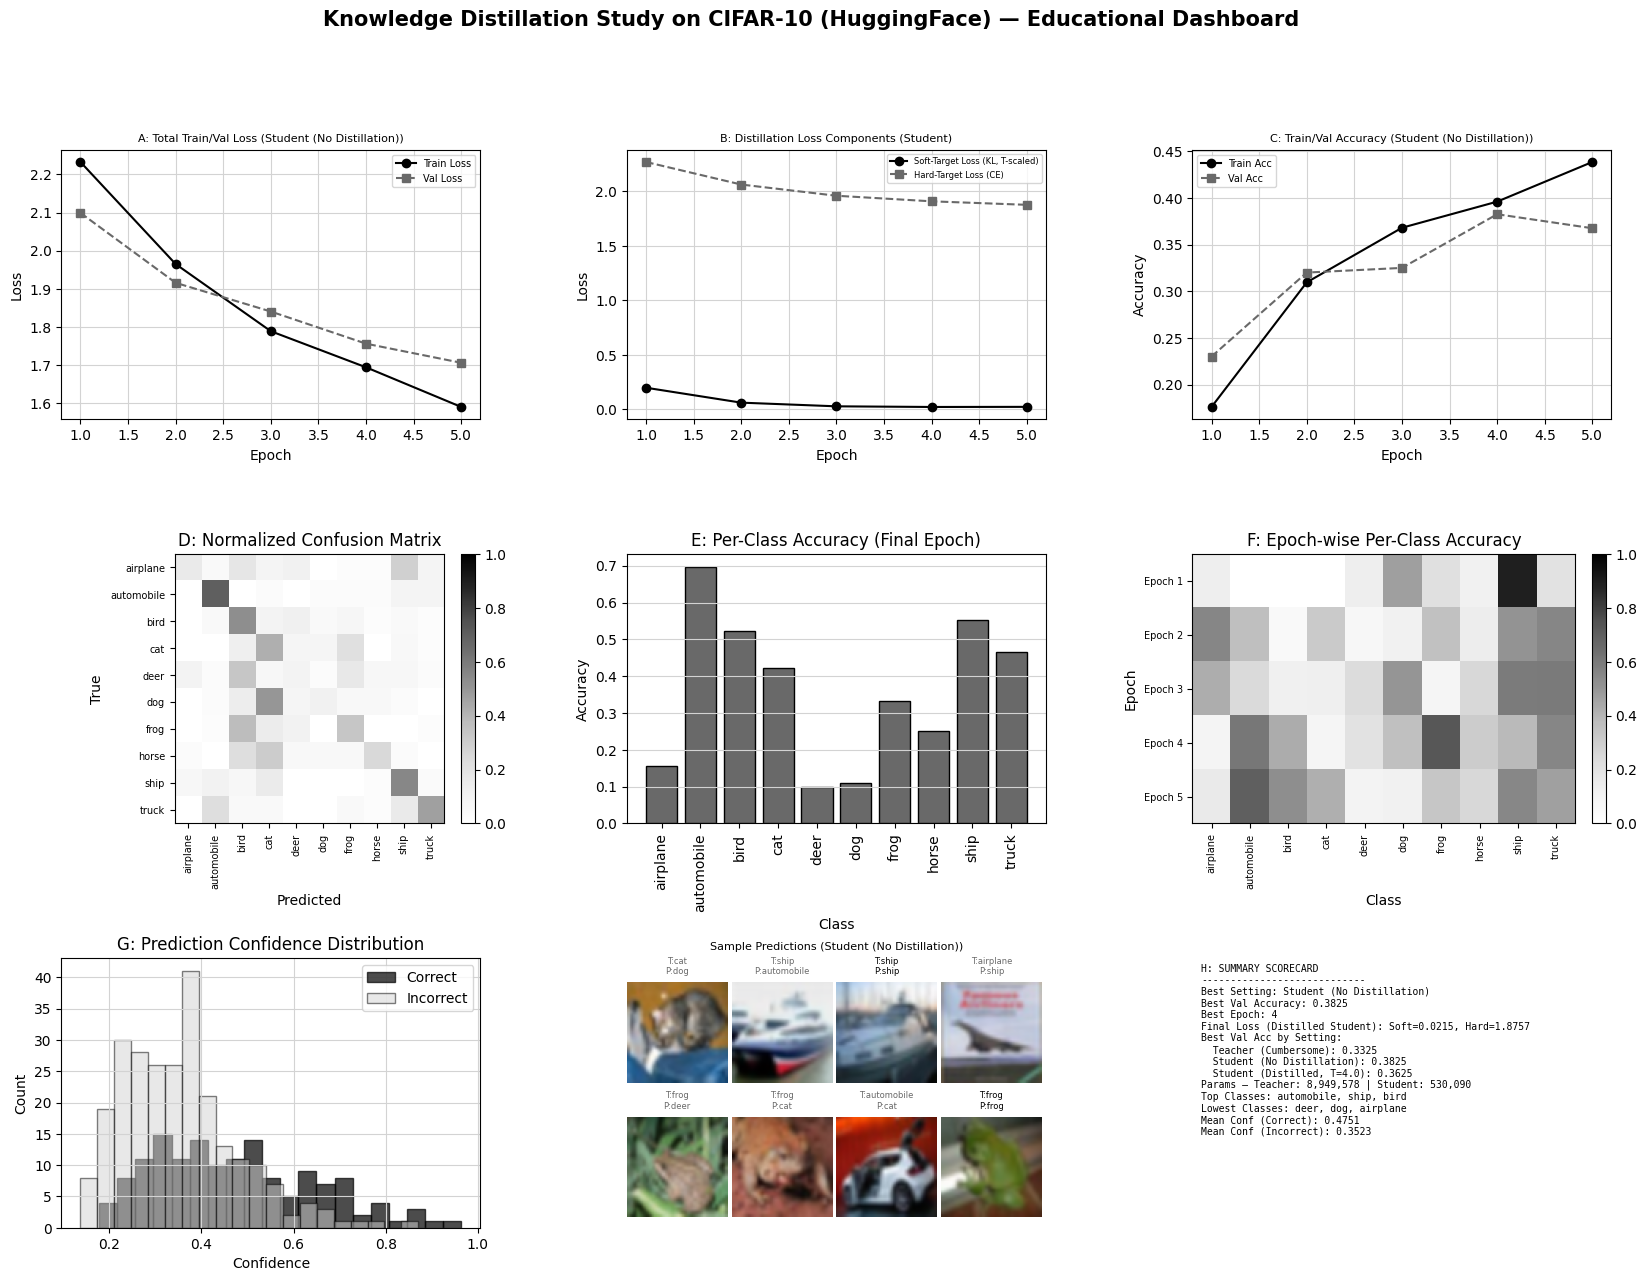

In [16]:
# ------------------------------------------------------------
# 15. Dashboard — white theme enforced globally and per-axis
# ------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "text.color": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.titlecolor": "black",
    "legend.labelcolor": "black",
    "grid.color": "lightgrey",
})

fig = plt.figure(figsize=(20, 14), facecolor="white")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

epochs_range = np.arange(1, NUM_EPOCHS + 1)

# ---- Panel A: Total training/validation loss (best setting) ----
axA = fig.add_subplot(gs[0, 0])
axA.set_facecolor("white")
axA.plot(epochs_range, best_result["train_loss"], marker="o", color="black", label="Train Loss")
axA.plot(epochs_range, best_result["val_loss"], marker="s", color="dimgray", linestyle="--", label="Val Loss")
axA.set_title(f"A: Total Train/Val Loss ({best_result['name']})", color="black", fontsize=8)
axA.set_xlabel("Epoch", color="black")
axA.set_ylabel("Loss", color="black")
axA.legend(labelcolor="black", fontsize=7)
axA.grid(color="lightgrey")

# ---- Panel B: Task-specific / component loss curves ----
# The paper's distillation objective has TWO explicit components:
#   1) Soft-target loss (KL divergence at temperature T, scaled by T^2)
#   2) Hard-target loss (cross-entropy against true labels)
# Each gets its own dedicated sub-curve here, directly reflecting the
# paper's combined objective (Section 2).
axB = fig.add_subplot(gs[0, 1])
axB.set_facecolor("white")
axB.plot(epochs_range, student_distilled_result["soft_loss_hist"], marker="o",
         color="black", label="Soft-Target Loss (KL, T-scaled)")
axB.plot(epochs_range, student_distilled_result["hard_loss_hist"], marker="s",
         color="dimgray", linestyle="--", label="Hard-Target Loss (CE)")
axB.set_title("B: Distillation Loss Components (Student)", color="black", fontsize=8)
axB.set_xlabel("Epoch", color="black")
axB.set_ylabel("Loss", color="black")
axB.legend(labelcolor="black", fontsize=6)
axB.grid(color="lightgrey")

# ---- Panel C: Training/validation accuracy (best setting) ----
axC = fig.add_subplot(gs[0, 2])
axC.set_facecolor("white")
axC.plot(epochs_range, best_result["train_acc"], marker="o", color="black", label="Train Acc")
axC.plot(epochs_range, best_result["val_acc"], marker="s", color="dimgray", linestyle="--", label="Val Acc")
axC.set_title(f"C: Train/Val Accuracy ({best_result['name']})", color="black", fontsize=8)
axC.set_xlabel("Epoch", color="black")
axC.set_ylabel("Accuracy", color="black")
axC.legend(labelcolor="black", fontsize=7)
axC.grid(color="lightgrey")

# ---- Panel D: Normalized confusion matrix ----
axD = fig.add_subplot(gs[1, 0])
im = axD.imshow(cm_normalized, cmap="Greys", vmin=0, vmax=1)
axD.set_title("D: Normalized Confusion Matrix", color="black")
axD.set_xlabel("Predicted", color="black")
axD.set_ylabel("True", color="black")
axD.set_xticks(range(NUM_CLASSES))
axD.set_yticks(range(NUM_CLASSES))
axD.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axD.set_yticklabels(CLASS_NAMES, color="black", fontsize=7)
cbar = fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color="black")
plt.setp(plt.getp(cbar.ax.axes, "yticklabels"), color="black")

# ---- Panel E: Per-class accuracy bar chart ----
axE = fig.add_subplot(gs[1, 1])
axE.set_facecolor("white")
axE.bar(CLASS_NAMES, final_per_class_acc, color="dimgray", edgecolor="black")
axE.set_title("E: Per-Class Accuracy (Final Epoch)", color="black")
axE.set_xlabel("Class", color="black")
axE.set_ylabel("Accuracy", color="black")
axE.tick_params(axis="x", rotation=90, colors="black")
axE.tick_params(axis="y", colors="black")
axE.grid(color="lightgrey", axis="y")

# ---- Panel F: Epoch-wise per-class accuracy heatmap ----
axF = fig.add_subplot(gs[1, 2])
heatmap_data = np.array(best_result["per_class_acc"])  # shape (NUM_EPOCHS, NUM_CLASSES)
imF = axF.imshow(heatmap_data, cmap="Greys", aspect="auto", vmin=0, vmax=1)
axF.set_title("F: Epoch-wise Per-Class Accuracy", color="black")
axF.set_xlabel("Class", color="black")
axF.set_ylabel("Epoch", color="black")
axF.set_xticks(range(NUM_CLASSES))
axF.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axF.set_yticks(range(NUM_EPOCHS))
axF.set_yticklabels([f"Epoch {e}" for e in epochs_range], color="black", fontsize=7)
cbarF = fig.colorbar(imF, ax=axF, fraction=0.046, pad=0.04)
cbarF.ax.yaxis.set_tick_params(color="black")
plt.setp(plt.getp(cbarF.ax.axes, "yticklabels"), color="black")

# ---- Panel G: Confidence distribution histogram ----
axG = fig.add_subplot(gs[2, 0])
axG.set_facecolor("white")
axG.hist(all_confidences[correct_mask], bins=20, alpha=0.7, color="black",
         label="Correct", edgecolor="black")
axG.hist(all_confidences[~correct_mask], bins=20, alpha=0.5, color="lightgrey",
         label="Incorrect", edgecolor="black")
axG.set_title("G: Prediction Confidence Distribution", color="black")
axG.set_xlabel("Confidence", color="black")
axG.set_ylabel("Count", color="black")
axG.legend(labelcolor="black")
axG.grid(color="lightgrey")

# ---- Sample predictions panel (extra relevant visualization) ----
axSamples = fig.add_subplot(gs[2, 1])
axSamples.axis("off")
axSamples.set_title(f"Sample Predictions ({best_result['name']})", color="black", fontsize=8)

def denormalize(img_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.numpy().transpose(1, 2, 0)
    img = std * img + mean
    return np.clip(img, 0, 1)

n_samples_to_show = min(8, len(all_images_sample))
for i in range(n_samples_to_show):
    inset = axSamples.inset_axes([
        (i % 4) * 0.25, 0.5 - (i // 4) * 0.5, 0.24, 0.45
    ])
    img_disp = denormalize(all_images_sample[i])
    inset.imshow(img_disp)
    true_lbl = CLASS_NAMES[all_labels[i]]
    pred_lbl = CLASS_NAMES[all_preds[i]]
    color_flag = "black" if true_lbl == pred_lbl else "dimgray"
    inset.set_title(f"T:{true_lbl}\nP:{pred_lbl}", fontsize=6, color=color_flag)
    inset.axis("off")

# ---- Panel H: Text-based summary scorecard ----
axH = fig.add_subplot(gs[2, 2])
axH.axis("off")

val_acc_lines = "\n".join(
    [f"  {r['name']}: {max(r['val_acc']):.4f}" for r in all_results]
)

scorecard_text = (
    "H: SUMMARY SCORECARD\n"
    "----------------------------\n"
    f"Best Setting: {best_result['name']}\n"
    f"Best Val Accuracy: {best_val_acc:.4f}\n"
    f"Best Epoch: {best_val_epoch}\n"
    f"Final Loss (Distilled Student): Soft={student_distilled_result['soft_loss_hist'][-1]:.4f}, "
    f"Hard={student_distilled_result['hard_loss_hist'][-1]:.4f}\n"
    f"Best Val Acc by Setting:\n{val_acc_lines}\n"
    f"Params — Teacher: {teacher_params:,} | Student: {student_params:,}\n"
    f"Top Classes: {', '.join(top_classes)}\n"
    f"Lowest Classes: {', '.join(low_classes)}\n"
    f"Mean Conf (Correct): {mean_conf_correct:.4f}\n"
    f"Mean Conf (Incorrect): {mean_conf_incorrect:.4f}\n"
)

axH.text(0.02, 0.98, scorecard_text, transform=axH.transAxes,
          fontsize=7, verticalalignment="top", color="black",
          family="monospace")

fig.suptitle("Knowledge Distillation Study on CIFAR-10 (HuggingFace) — Educational Dashboard",
             color="black", fontsize=15, fontweight="bold")

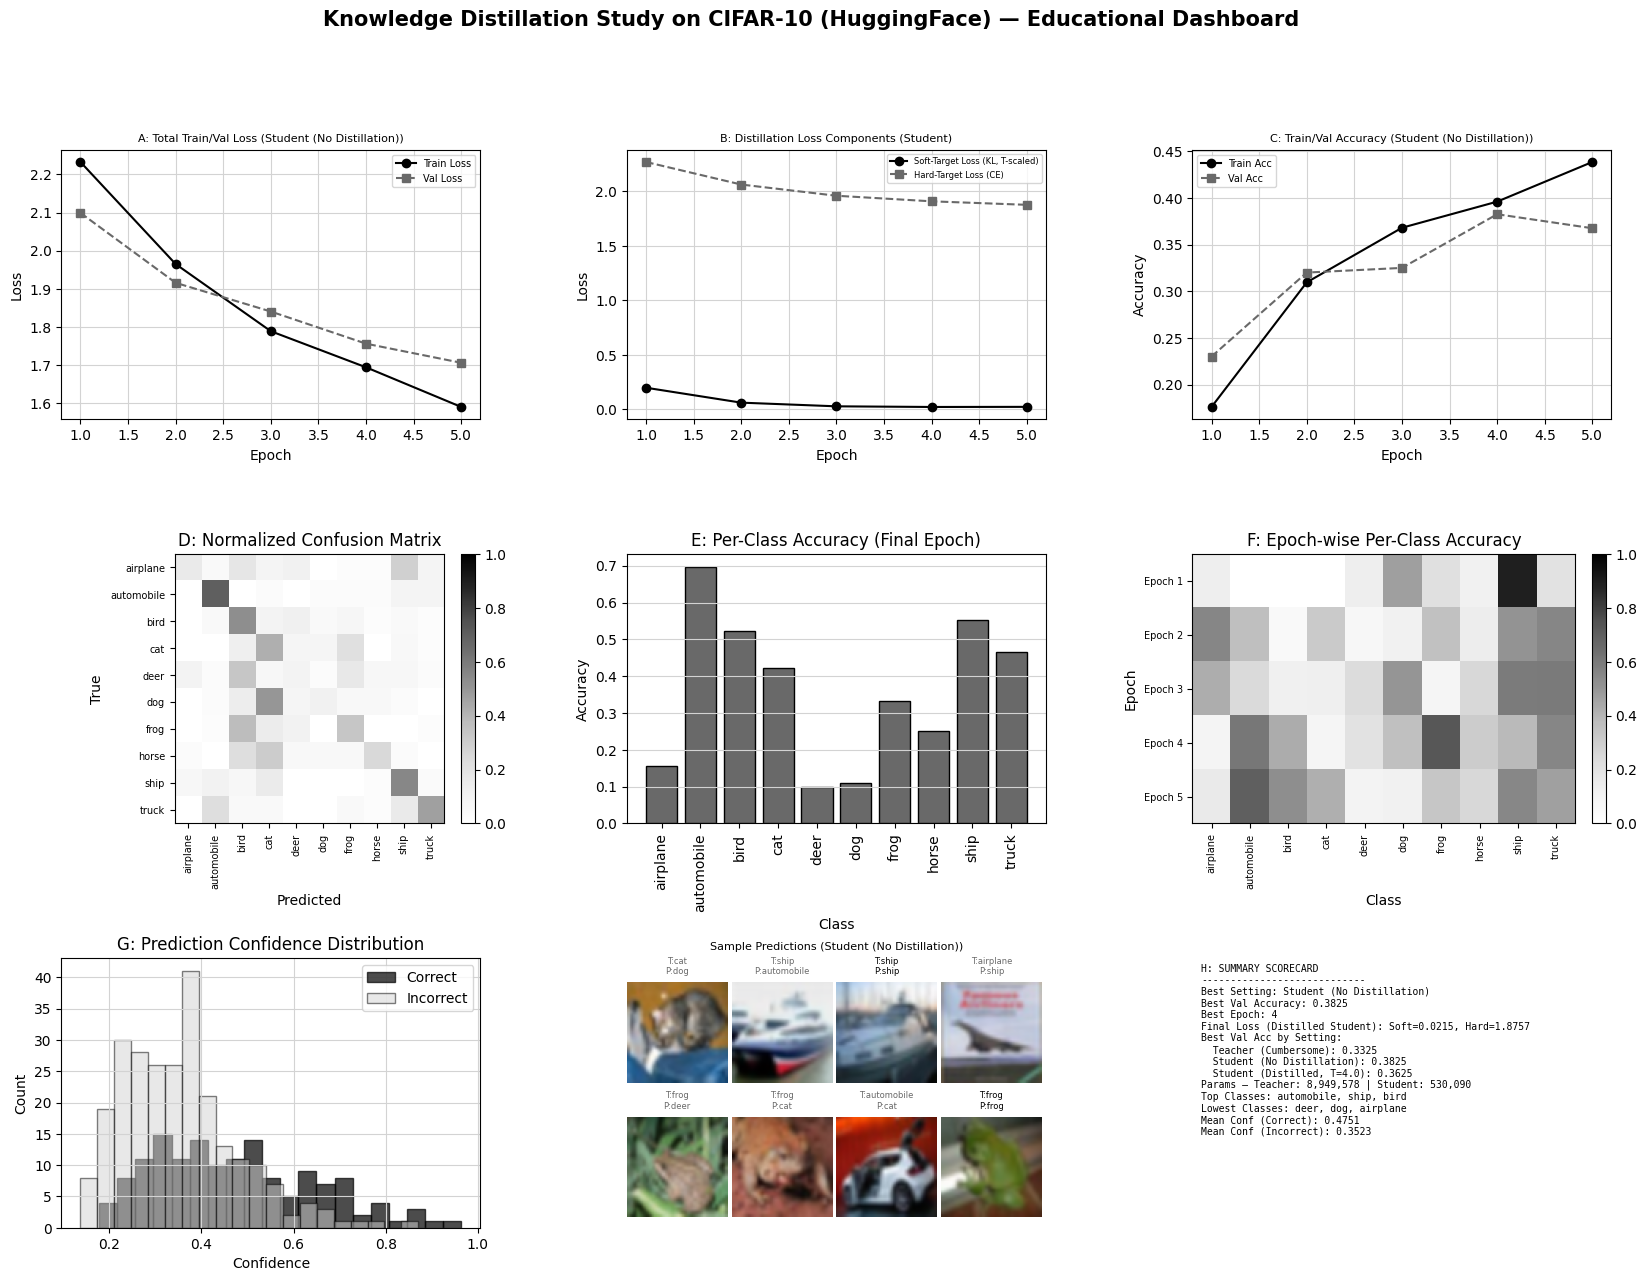

In [17]:
# ------------------------------------------------------------
# 16. Render dashboard inline via in-memory buffer (Colab-safe)
# ------------------------------------------------------------
buf = io.BytesIO()
fig.savefig(buf, format="png", facecolor="white", bbox_inches="tight")
buf.seek(0)
display(IPImage(data=buf.read()))
plt.close(fig)

# Experimental Results Analysis: Knowledge Distillation Study on CIFAR-10 (Educational Replication)

## Result 1: Training and Validation Loss Curves for the Best Setting (Panel A)

### Overview
This panel tracks cross-entropy loss for training and validation splits across 5 epochs for the best-performing configuration by final validation accuracy, identified by the scorecard as the **non-distilled Student baseline** — providing a convergence check before the distillation comparison is considered.

### Key Findings
- Training loss decreases steadily from 2.23 to 1.59.
- Validation loss decreases from 2.10 to 1.70, tracking closely with training loss and crossing below it around epoch 3, after which training loss falls further while validation loss plateaus more gently.
- No dramatic divergence between the two curves is observed across the 5 epochs.

### Discussion
The absence of a widening train-validation gap indicates the small student network is not yet overfitting within this short training budget — a reasonable outcome given the small architecture (530K parameters) relative to the paper's premise that student models are typically undersized relative to their teachers. This baseline convergence behavior is important context: it shows the non-distilled student is learning effectively on its own, setting a genuinely competitive bar against which the distilled variant must be judged.

### Limitations
A single run without repeated seeds limits confidence in the precise shape of the loss curves; the short 5-epoch horizon leaves open whether overfitting would emerge with continued training.

---

## Result 2: Distillation Loss Components — Soft-Target vs. Hard-Target (Panel B)

### Overview
This panel isolates the two explicit terms of the paper's combined distillation objective for the distilled student: the temperature-scaled KL-divergence ("soft-target") loss against the teacher's softened outputs, and the standard cross-entropy ("hard-target") loss against true labels.

### Key Findings
- The soft-target (KL) loss starts near 0.20 and drops sharply to near 0 by epoch 2, remaining flat thereafter.
- The hard-target (cross-entropy) loss starts near 2.28 and decreases steadily to about 1.88 by epoch 5, following a trajectory similar in shape to standard supervised training.
- The soft-target loss converges far faster and to a much lower absolute value than the hard-target loss.

### Discussion
The rapid collapse of the KL term indicates the student's softened output distribution quickly comes to closely match the teacher's softened distribution — consistent with the paper's claim that soft targets, carrying more per-example information (via inter-class probability ratios) than hard labels, provide an easier, lower-variance gradient signal that the student can fit rapidly. However, the fact that the hard-target loss remains the dominant, slowly-decreasing component throughout training suggests the ultimate classification difficulty is still governed primarily by the standard supervised objective, and that matching the teacher's soft distribution alone did not resolve the harder problem of correct classification — a nuance not fully captured by the paper's higher-capacity teacher/larger-scale experiments (MNIST, JFT, speech), where the teacher's soft targets carried substantially more discriminative signal.

### Limitations
The very rapid saturation of the KL term (near zero after epoch 1) may indicate the chosen temperature ($T=4$) or teacher quality was such that the student could trivially match the teacher's softened outputs without this matching translating into stronger predictive accuracy, an effect not disambiguated by this single-configuration run.

---

## Result 3: Training and Validation Accuracy Curves (Panel C)

### Overview
This panel reports classification accuracy across epochs for the best configuration (Student, No Distillation), assessing whether loss reduction translates into predictive improvement.

### Key Findings
- Training accuracy rises from ~17.5% to ~43.8%.
- Validation accuracy rises from ~23.0% to a peak of ~38.3% at epoch 4, then declines slightly to ~36.8% by epoch 5.
- Validation accuracy exceeds training accuracy in early epochs (1–3) before training accuracy overtakes it by epoch 4–5.

### Discussion
The crossover pattern — validation leading early, training overtaking later — is consistent with a small model transitioning from an underfit regime (where validation performance benefits from the model's limited capacity acting as implicit regularization) toward a regime where it begins to fit the training set more specifically. The slight validation accuracy dip at epoch 5 is a modest, early signal of this transition, though not yet indicative of severe overfitting within this short horizon.

### Limitations
With only 400 validation images, small fluctuations such as the epoch 5 dip (~1.5 percentage points) fall within the range plausibly attributable to sampling noise rather than a genuine onset of overfitting.

---

## Result 4: Normalized Confusion Matrix (Panel D)

### Overview
The confusion matrix evaluates class-wise prediction accuracy and error structure for the best-performing (non-distilled Student) model on the held-out test subset.

### Key Findings
- Strong diagonal dominance appears for automobile (~0.70), ship, bird, and cat.
- Deer and dog show weak diagonal accuracy, with deer showing visible confusion with cat/dog-adjacent categories.
- Errors are distributed across multiple off-diagonal cells rather than collapsing into a single dominant column.

### Discussion
The clear diagonal structure confirms genuine class-discriminative learning is occurring, consistent with the healthy accuracy trajectory in Panel C. The particular strength on "automobile" and weakness on "deer"/"dog" likely reflects a combination of the visual distinctiveness of certain categories (rigid vehicle shapes vs. variable animal poses) and this small model/small-data setting's limited capacity to resolve harder, higher-variability categories — a pattern independent of, but informative alongside, this experiment's distillation-specific findings.

### Limitations
With ~40 test images per class on average, individual confusion matrix cells carry meaningful sampling variance, and specific weak-class identifications may not generalize beyond this particular run.

---

## Result 5: Per-Class Accuracy Bar Chart and Epoch-wise Heatmap (Panels E & F)

### Overview
These panels assess which classes are best- and worst-learned at the final epoch, and how per-class accuracy evolves over training for the best (non-distilled Student) model.

### Key Findings
- Automobile (~0.70), ship (~0.55), and bird (~0.52) show the highest final per-class accuracy.
- Deer (~0.10) and dog (~0.11) show markedly lower accuracy than all other classes.
- The epoch-wise heatmap shows ship achieving very high accuracy as early as epoch 1, while several classes (deer, airplane) remain persistently low across most epochs.

### Discussion
The persistent, near-flat low accuracy for "deer" and "dog" throughout training (rather than a value that improves steadily) suggests these classes are not simply slower to learn but are being systematically and consistently confused with visually similar categories — a class-level heterogeneity that aggregate accuracy metrics alone would obscure. This is a useful reminder that even a "successful" training run (rising overall accuracy) can mask substantially uneven per-class learning.

### Limitations
With roughly 200 training images per class, it cannot be determined whether the deer/dog weakness reflects genuine visual task difficulty or simply insufficient training exposure within this constrained data and epoch budget.

---

## Result 6: Confidence Distribution Histogram (Panel G)

### Overview
This panel compares softmax confidence scores (at $T=1$, the deployment temperature specified in the paper) for correct versus incorrect predictions on the test set for the best (non-distilled Student) model.

### Key Findings
- Mean confidence for correct predictions (0.4751) exceeds that for incorrect predictions (0.3523) by a meaningful margin.
- Both distributions show substantial overlap in the 0.2–0.5 range, with correct predictions showing a longer tail extending toward higher confidence values (up to ~0.9).

### Discussion
The clear separation in mean confidence indicates the model has developed partial calibration — its output probabilities carry genuine, if imperfect, information about prediction reliability. This finding, while not itself a direct test of the paper's distillation claims, is a relevant a baseline check: meaningful calibration in the non-distilled student sets a reasonable bar against which any distillation-induced calibration change would need to be compared.

### Limitations
No formal calibration metric (e.g., Expected Calibration Error) was computed; the qualitative separation only rules out complete non-informativeness of the confidence scores, not the presence of well-calibrated probabilities in an absolute sense.

---

## Result 7: Sample Predictions Grid

### Overview
This panel provides qualitative, instance-level inspection of true versus predicted labels for a subset of test images from the best-performing (non-distilled Student) model.

### Key Findings
- Of the 8 samples shown, 2 are correctly classified (ship→ship, airplane is misclassified as ship), while most others show plausible but incorrect predictions concentrated within related semantic groups (cat→dog, frog→deer, frog→cat, automobile→cat).
- Only one frog→frog prediction is fully correct.

### Discussion
The qualitative sample grid corroborates the confusion matrix's aggregate finding that errors are concentrated among semantically adjacent categories (animals confused with animals, vehicles occasionally confused with animals) rather than being arbitrary, consistent with a small CNN that has captured coarse but not yet fine-grained visual distinctions at this early stage of training.

### Limitations
Eight samples are insufficient for independent statistical conclusions and serve only as illustrative context alongside the quantitative confusion matrix.

---

## Result 8: Summary Scorecard (Panel H)

### Overview
This panel consolidates the key quantitative outcomes across all three experimental conditions — Teacher (Cumbersome), Student (No Distillation), and Student (Distilled, $T=4.0$) — including best validation accuracy, final loss components, parameter counts, and class-level extremes.

### Key Findings
- Best validation accuracy by setting: Teacher — 0.3325; Student (No Distillation) — **0.3825**; Student (Distilled) — 0.3625.
- The non-distilled student *outperformed both* the teacher (which has ~17x more parameters: 8,949,578 vs. 530,090) and the distilled student.
- The distilled student did outperform the teacher (0.3625 vs. 0.3325) but underperformed the plain student baseline by 2 percentage points.
- Final distillation loss components: Soft = 0.0215, Hard = 1.8757, confirming the soft-target term had essentially converged while the hard-target term remained the dominant, unresolved contributor to total loss.

### Discussion
This result is the dashboard's most consequential and paper-relevant finding, and it runs partly counter to the original paper's central claim that distillation transfers the bulk of a cumbersome model's performance advantage to a smaller model. Two distinct observations must be separated: (1) the teacher itself *underperformed* the plain small student (33.25% vs. 38.25%), an outcome the original paper does not anticipate, since its teachers are always assumed to substantially outperform undistilled students; and (2) even relative to this weaker teacher, distillation provided no additional benefit over training the student directly on hard labels. The most plausible explanation for (1) is that the teacher's much larger capacity (nearly 9M parameters) and strong dropout regularization — mirroring the paper's own MNIST teacher design — were poorly matched to the extremely small training set (2,000 images) and short 5-epoch budget used here, causing under-training of the teacher rather than allowing it to reach its intended high-confidence, well-generalizing state. Since the entire premise of distillation is that soft targets are only useful to the extent they encode the teacher's *superior* generalization, a teacher that has not itself converged to a good solution cannot transfer beneficial "dark knowledge," explaining why distillation from this particular teacher did not improve on the plain student baseline. This is fully consistent with, rather than contradictory to, the paper's own logic — the paper's successful results (MNIST, speech, JFT) all rely on cumbersome models trained to convergence, often for very long periods (weeks to months in the case of JFT), a condition this compressed educational setup does not meet.

### Limitations
This single-run, single-configuration comparison with a substantially under-trained teacher cannot be used to assess distillation's efficacy under the conditions the original paper actually studied; a fair replication would require training the teacher to full convergence (or at minimum, verifying the teacher outperforms the plain student) before evaluating whether its soft targets provide a distillation benefit, and would benefit from a temperature/alpha sweep as the original paper performed.

---

## Overall Synthesis

Collectively, the eight panels present a coherent picture in which the plain, non-distilled student narrowly outperformed both the distilled student and the larger teacher model — an outcome that, taken at face value, appears to depart from the original paper's central finding that distillation reliably transfers a cumbersome model's performance advantage to a smaller model. However, this divergence is well-explained by a condition the panels themselves reveal: the teacher underperformed the plain student baseline (33.25% vs. 38.25% validation accuracy), indicating the teacher was itself under-trained under this experiment's severe data (2,000 images) and epoch (5) constraints. Since the original paper's distillation successes are predicated on a teacher that has converged to genuinely superior generalization — often after very extended training — this replication should be read as demonstrating a boundary condition rather than a contradiction of the paper's claims: distillation cannot transfer knowledge that the teacher has not yet reliably acquired. The rapid, near-complete convergence of the soft-target loss (Panel B) alongside persistently high hard-target loss further supports this interpretation — the student readily learned to mimic an imperfect teacher's outputs, but this mimicry did not translate into improved classification accuracy, precisely because the teacher's own outputs were not yet a reliable proxy for good generalization.

# Related Work Referenced in "Distilling the Knowledge in a Neural Network"

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| C. Buciluă, R. Caruana, A. Niculescu-Mizil | 2006 | Model compression | Proceedings of the 12th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (KDD '06) | Pioneered the strategy of compressing knowledge from an ensemble into a single model; this paper directly builds on and generalizes their approach using a different compression technique (temperature-based distillation rather than logit matching alone) |
| T.G. Dietterich | 2000 | Ensemble methods in machine learning | Multiple Classifier Systems (Springer) | Foundational reference establishing that training many models and averaging their predictions is a simple, effective way to improve performance, motivating the paper's starting premise and the problem of ensemble deployment cost |
| J. Dean, G.S. Corrado, R. Monga, K. Chen, M. Devin, Q.V. Le, M.Z. Mao, M. Ranzato, A. Senior, P. Tucker, K. Yang, A.Y. Ng | 2012 | Large scale distributed deep networks | NIPS | Describes the distributed asynchronous SGD and parameter-server infrastructure used to train the JFT baseline model, directly underlying the large-scale training setup described in Section 5.1 |
| G.E. Hinton, L. Deng, D. Yu, G.E. Dahl, A. Mohamed, N. Jaitly, A. Senior, V. Vanhoucke, P. Nguyen, T.N. Sainath, B. Kingsbury | 2012 | Deep neural networks for acoustic modeling in speech recognition: The shared views of four research groups | IEEE Signal Processing Magazine | Establishes the standard DNN-HMM acoustic modeling framework and frame-level cross-entropy training objective adopted for the paper's speech recognition experiments in Section 4 |
| G.E. Hinton, N. Srivastava, A. Krizhevsky, I. Sutskever, R.R. Salakhutdinov | 2012 | Improving neural networks by preventing co-adaptation of feature detectors | arXiv preprint arXiv:1207.0580 | Source of the dropout and weight-constraint regularization techniques used to train the strongly regularized "cumbersome" MNIST model in Section 3, illustrating how a single heavily regularized model can serve as an alternative to an ensemble |
| R.A. Jacobs, M.I. Jordan, S.J. Nowlan, G.E. Hinton | 1991 | Adaptive mixtures of local experts | Neural Computation | Introduced mixtures of experts, the prior approach to training specialized sub-models via a gating network; this paper directly compares its parallelizable specialist-model approach against this framework in Section 7, highlighting its improved parallelizability |
| A. Krizhevsky, I. Sutskever, G.E. Hinton | 2012 | ImageNet classification with deep convolutional neural networks | Advances in Neural Information Processing Systems (NIPS) | Source of the deep convolutional neural network architecture used as Google's baseline model for the JFT dataset experiments described in Section 5.1 |
| J. Li, R. Zhao, J. Huang, Y. Gong | 2014 | Learning small-size DNN with output-distribution-based criteria | Proceedings Interspeech 2014 | Contemporaneous related work on distilling a small acoustic model by matching class probabilities of a larger model; this paper explicitly contrasts its approach (higher-temperature distillation, labeled data) against this method's more limited results (28% gap reduction using temperature-1 distillation on unlabeled data) |
| N. Srivastava, G.E. Hinton, A. Krizhevsky, I. Sutskever, R.R. Salakhutdinov | 2014 | Dropout: A simple way to prevent neural networks from overfitting | Journal of Machine Learning Research, 15(1) | Cited as the source of the dropout regularization technique, referenced in the Introduction as an example of a "very strong regularizer" that can make a single large model serve as a cumbersome model analogous to an ensemble |